# 02 — Exploratory Data Analysis

**Home Energy Copilot** — CPSC 393 Final Project

Goals of this notebook:

1. Confirm the cleaned data loaded by `01_data_loading` looks right.
2. Compare weighted vs. unweighted summary statistics so we know whether `NWEIGHT` materially changes the picture (it does).
3. Show the distribution of the regression target (`TOTALDOL`) and the within-climate normalization (`cost_per_sqft`).
4. Validate that efficiency classes are balanced inside every peer group.
5. Identify the strongest correlates of `TOTALDOL` to inform feature selection.
6. Examine end-use cost shares by efficiency class — does 'inefficient' really mean heat/cool waste?
7. Quantify sentinel-value impact so we can decide on encoding strategy in `03_classification` and `04_regression`.

## Setup

In [1]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR     = os.path.join(PROJECT_ROOT, 'data')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

df = pd.read_pickle(os.path.join(DATA_DIR, 'recs2020_clean.pkl'))
meta = json.load(open(os.path.join(DATA_DIR, 'recs2020_clean_meta.json')))
print('shape:', df.shape)
df.head(3)


shape: (18495, 69)


,DOEID,NWEIGHT,BA_climate,BA_climate_grp,TOTALDOL,TOTSQFT_EN,cost_per_sqft,efficiency_class,heat_cool_dol,water_heat_dol,...,TYPERFR1,TYPETHERM,WALLTYPE,WASHTEMP,WHEATAGE,WHEATSIZ,WINDOWS,WINFRAME,YEARMADERANGE,state_postal
0,100001,3284.103668,Mixed-Dry,Mixed-Dry,2656.89,2100,1.265186,inefficient,1169.563758,146.263361,...,5,1,1,3,1,3,4,3,4,NM
1,100002,9007.387470,Mixed-Humid,Mixed-Humid,975.00,590,1.652542,inefficient,465.782599,261.730000,...,1,1,1,3,4,2,1,1,5,AR
2,100003,5669.002142,Mixed-Dry,Mixed-Dry,522.65,900,0.580722,efficient,384.180620,46.690318,...,-2,1,1,-2,5,4,1,2,3,NM


## Weighted helpers

RECS households carry a `NWEIGHT` representing how many U.S. households each survey row stands for. Every summary statistic and metric in this project should respect those weights so we describe the U.S. population, not the survey sample.

In [2]:
def wmean(s, w):
    return float(np.average(s, weights=w))

def wquantile(s, w, q):
    s = np.asarray(s); w = np.asarray(w)
    idx = np.argsort(s); s = s[idx]; w = w[idx]
    cum = np.cumsum(w) / w.sum()
    return float(np.interp(q, cum, s))

w = df['NWEIGHT']
print(f"unweighted: mean ${df['TOTALDOL'].mean():.0f},   median ${df['TOTALDOL'].median():.0f}")
print(f"weighted:   mean ${wmean(df['TOTALDOL'], w):.0f},   median ${wquantile(df['TOTALDOL'], w, 0.5):.0f}")
print(f"NWEIGHT sum: {w.sum():,.0f}  (≈ # of U.S. households)")


unweighted: mean $1990,   median $1793
weighted:   mean $1884,   median $1713
NWEIGHT sum: 123,524,204  (≈ # of U.S. households)


## Target variable distribution

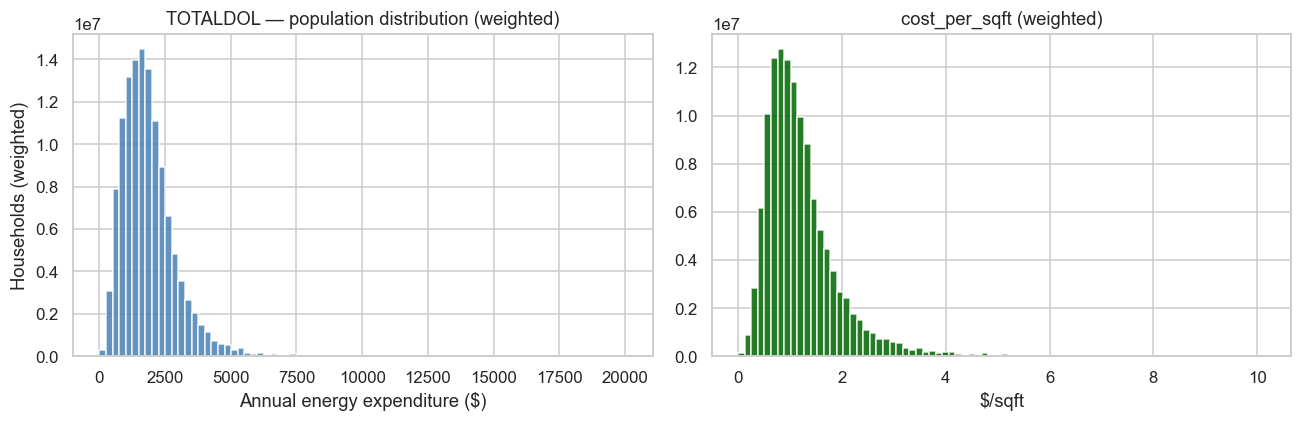

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(df['TOTALDOL'], bins=80, weights=w, color='steelblue', alpha=0.85)
ax[0].set_title('TOTALDOL — population distribution (weighted)')
ax[0].set_xlabel('Annual energy expenditure ($)')
ax[0].set_ylabel('Households (weighted)')
ax[1].hist(df['cost_per_sqft'], bins=80, weights=w, color='darkgreen', alpha=0.85)
ax[1].set_title('cost_per_sqft (weighted)')
ax[1].set_xlabel('$/sqft')
plt.tight_layout()
plt.show()


## Cost per square foot by climate peer group

Within-climate tertiles only make sense if `cost_per_sqft` actually varies by climate — this confirms it.

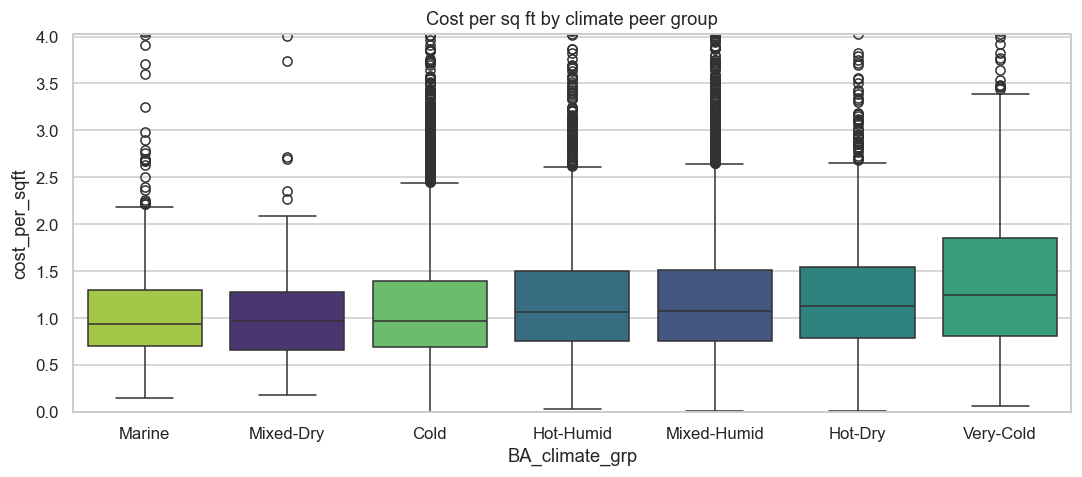

In [4]:
order = (df.groupby('BA_climate_grp', observed=True)['cost_per_sqft']
           .median().sort_values().index.tolist())
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.boxplot(data=df, x='BA_climate_grp', y='cost_per_sqft', order=order, ax=ax,
            hue='BA_climate_grp', palette='viridis', legend=False)
ax.set_ylim(0, df['cost_per_sqft'].quantile(0.99))
ax.set_title('Cost per sq ft by climate peer group')
plt.tight_layout()
plt.show()


## Class balance check

Tertiles are computed *within* each peer group, so each cell should be ~33%. This sanity check protects against later modeling pitfalls.

efficiency_class  efficient  average  inefficient
BA_climate_grp                                   
Cold                   2372     2371         2372
Hot-Dry                 526      525          526
Hot-Humid               848      849          848
Marine                  304      303          304
Mixed-Dry                48       47           47
Mixed-Humid            1860     1859         1860
Very-Cold               209      208          209

Row shares (should ≈ 0.33 each):
efficiency_class  efficient  average  inefficient
BA_climate_grp                                   
Cold                  0.333    0.333        0.333
Hot-Dry               0.334    0.333        0.334
Hot-Humid             0.333    0.334        0.333
Marine                0.334    0.333        0.334
Mixed-Dry             0.338    0.331        0.331
Mixed-Humid           0.333    0.333        0.333
Very-Cold             0.334    0.332        0.334


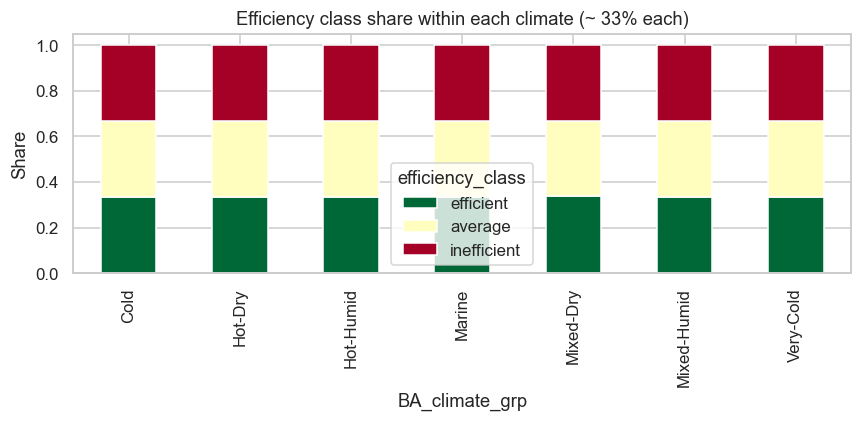

In [5]:
ct = (df.groupby(['BA_climate_grp','efficiency_class'], observed=True).size()
        .unstack(fill_value=0))
print(ct)
print()
print('Row shares (should ≈ 0.33 each):')
print(ct.div(ct.sum(axis=1), axis=0).round(3))

fig, ax = plt.subplots(figsize=(8, 4))
ct.div(ct.sum(axis=1), axis=0).plot(kind='bar', stacked=True, ax=ax, colormap='RdYlGn_r')
ax.set_title('Efficiency class share within each climate (~ 33% each)')
ax.set_ylabel('Share')
plt.tight_layout()
plt.show()


## End-use cost share by efficiency class

Where does the extra spending in 'inefficient' homes actually go? The recommendation engine is built around heat/cool, water heat, lighting, and fridge buckets, so this view tells us whether those are the right levers.

                  heat_cool_dol  water_heat_dol  lighting_dol  fridge_dol  \
efficiency_class                                                            
efficient                 0.427           0.157         0.049       0.080   
average                   0.428           0.165         0.050       0.069   
inefficient               0.404           0.180         0.047       0.060   

                  other_dol  
efficiency_class             
efficient             0.287  
average               0.289  
inefficient           0.308  


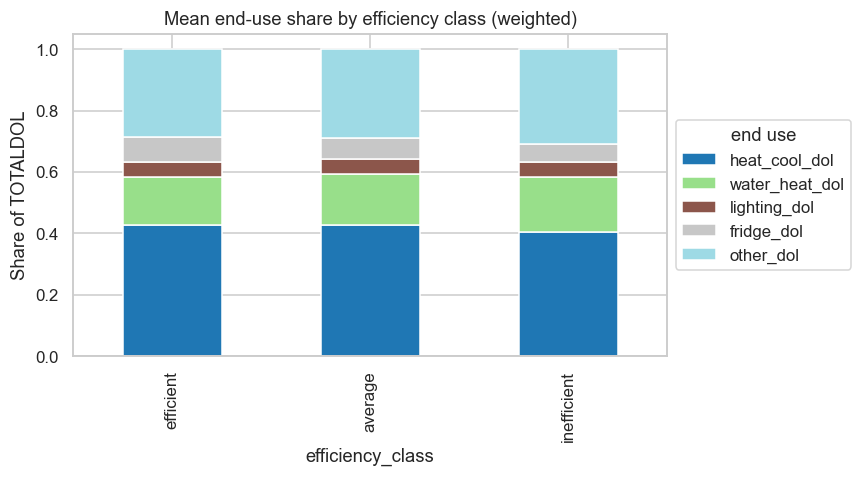

In [6]:
share_cols = ['heat_cool_dol','water_heat_dol','lighting_dol','fridge_dol','other_dol']

def weighted_share(group):
    return pd.Series({c: np.average(group[c]/group['TOTALDOL'], weights=group['NWEIGHT'])
                      for c in share_cols})

agg = (df.groupby('efficiency_class', observed=True)[share_cols + ['TOTALDOL','NWEIGHT']]
         .apply(weighted_share))
print(agg.round(3))

fig, ax = plt.subplots(figsize=(8, 4.5))
agg.plot(kind='bar', stacked=True, ax=ax, colormap='tab20')
ax.set_title('Mean end-use share by efficiency class (weighted)')
ax.set_ylabel('Share of TOTALDOL')
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), title='end use')
plt.tight_layout()
plt.show()


## Pearson correlations with TOTALDOL

Sentinel codes are masked to NaN for this view only — they would otherwise bias correlations.

Top negative correlations:
TYPEHUQ         -0.345214
FUELHEAT        -0.083906
ADQINSUL        -0.071243
CDD65           -0.056199
EMPLOYHH        -0.052683
WINFRAME        -0.044661
FUELH2O         -0.044654
YEARMADERANGE   -0.041104

Top positive correlations:
SIZRFRI1      0.253950
NHSLDMEM      0.315090
NUMFRIG       0.343976
NCOMBATH      0.360119
BEDROOMS      0.440202
TOTROOMS      0.461094
WINDOWS       0.473299
TOTSQFT_EN    0.493735


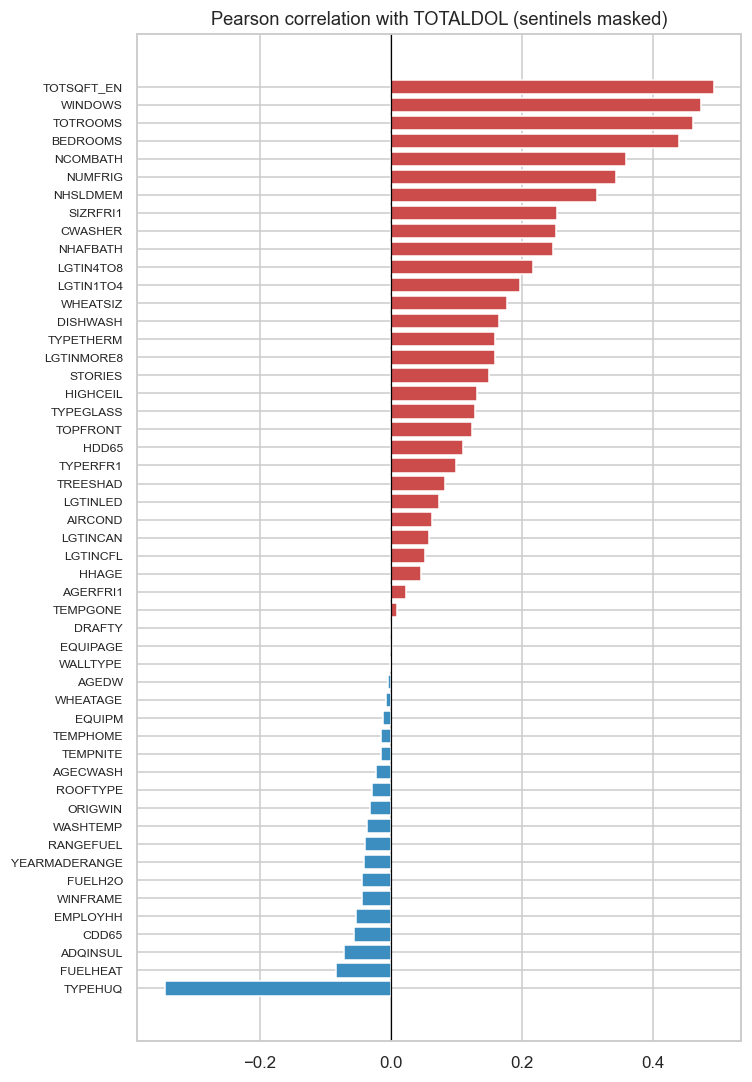

In [7]:
num_cols = [c for c in meta['all_features_present']
            if c in df.columns and pd.api.types.is_numeric_dtype(df[c])]
clean = df[num_cols + ['TOTALDOL']].replace({-2: np.nan, -9: np.nan})
corr = clean.corr()['TOTALDOL'].drop('TOTALDOL').sort_values()

print('Top negative correlations:')
print(corr.head(8).to_string())
print('\nTop positive correlations:')
print(corr.tail(8).to_string())

fig, ax = plt.subplots(figsize=(7, 10))
colors = ['#cc4c4c' if x > 0 else '#3c8ec0' for x in corr]
ax.barh(range(len(corr)), corr.values, color=colors)
ax.set_yticks(range(len(corr)))
ax.set_yticklabels(corr.index, fontsize=8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Pearson correlation with TOTALDOL (sentinels masked)')
plt.tight_layout()
plt.show()


**Reading the chart:** the top correlates are all *size* proxies (`TOTSQFT_EN`, `WINDOWS`, `TOTROOMS`, `BEDROOMS`, `NCOMBATH`). This validates normalizing by sqft for the classification target — otherwise the model would just be relearning 'big house = expensive.' The strongest negative correlate is `TYPEHUQ` (1=mobile home → 5=apartment in 5+ unit building), reflecting that apartments use less energy.

## Categorical EDA

Weighted-mean `TOTALDOL` for each level of four key categorical features.

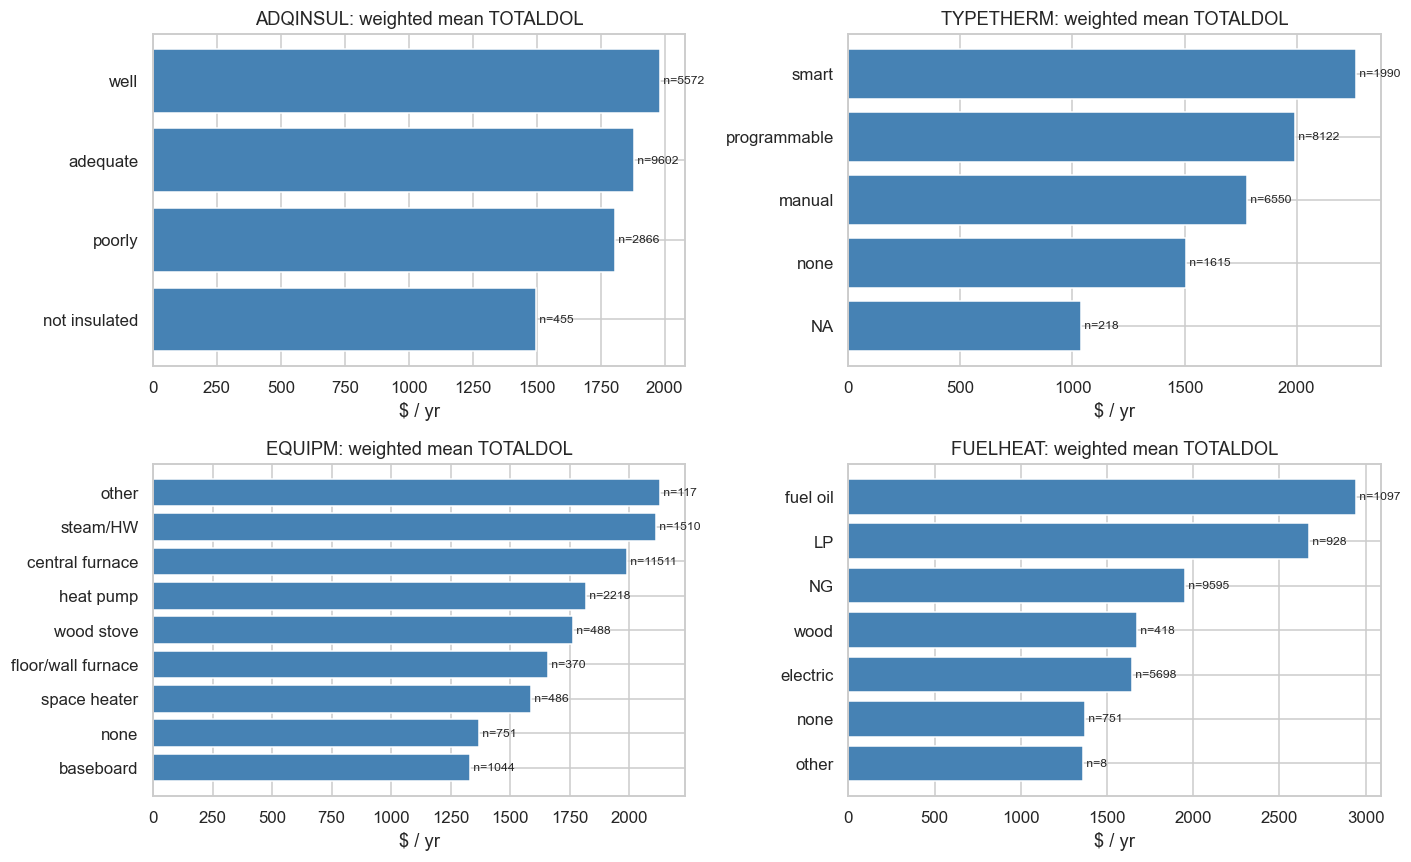

In [8]:
cat_targets = {
    'ADQINSUL':  {1:'well',2:'adequate',3:'poorly',4:'not insulated'},
    'TYPETHERM': {-2:'NA',0:'none',1:'manual',2:'programmable',3:'smart'},
    'EQUIPM':    {-2:'none',2:'steam/HW',3:'central furnace',4:'heat pump',
                  5:'baseboard',7:'wood stove',8:'floor/wall furnace',
                  10:'space heater',13:'space heater',99:'other'},
    'FUELHEAT':  {-2:'none',1:'NG',2:'LP',3:'fuel oil',5:'electric',7:'wood',99:'other'},
}

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, (col, mapping) in zip(axes.flatten(), cat_targets.items()):
    sub = df[[col, 'TOTALDOL', 'NWEIGHT']].copy()
    sub['label'] = sub[col].map(mapping).fillna(sub[col].astype(str))
    grp = (sub.groupby('label')[['TOTALDOL','NWEIGHT']]
              .apply(lambda g: pd.Series({
                  'n': len(g),
                  'wmean': np.average(g['TOTALDOL'], weights=g['NWEIGHT'])}))
              .sort_values('wmean'))
    ax.barh(grp.index, grp['wmean'], color='steelblue')
    ax.set_title(f'{col}: weighted mean TOTALDOL')
    ax.set_xlabel('$ / yr')
    for i, (v, n) in enumerate(zip(grp['wmean'], grp['n'])):
        ax.text(v, i, f' n={int(n)}', va='center', fontsize=8)
plt.tight_layout()
plt.show()


## Sentinel-value impact

Some features have a large share of `-2` ('not applicable') values — for example, `STORIES` is undefined for apartments, `AGEDW` for homes without a dishwasher. Naively dropping these rows would tank the sample. The downstream notebooks treat the sentinels as their own category in one-hot encoding rather than as missing data.

In [9]:
sent_cols = list(meta['columns_with_sentinels'].keys())
rows = []
for c in sent_cols:
    if c in df.columns and pd.api.types.is_numeric_dtype(df[c]):
        n = int(df[c].isin([-2, -9]).sum())
        rows.append((c, n, n/len(df)))
sent_df = pd.DataFrame(rows, columns=['feature','n_sentinels','share']).sort_values('n_sentinels', ascending=False)
sent_df.head(20).style.format({'share': '{:.1%}'})


,feature,n_sentinels,share
10,STORIES,4426,23.9%
1,AGEDW,4388,23.7%
8,ROOFTYPE,2439,13.2%
0,AGECWASH,2152,11.6%
14,TOPFRONT,2152,11.6%
17,WASHTEMP,2152,11.6%
7,RANGEFUEL,2067,11.2%
6,HIGHCEIL,974,5.3%
5,FUELHEAT,751,4.1%
4,EQUIPM,751,4.1%


## Heating-degree-days vs cooling-degree-days vs cost

Climate severity should drive heat/cool spending. This is a quick visual check that those features carry signal.

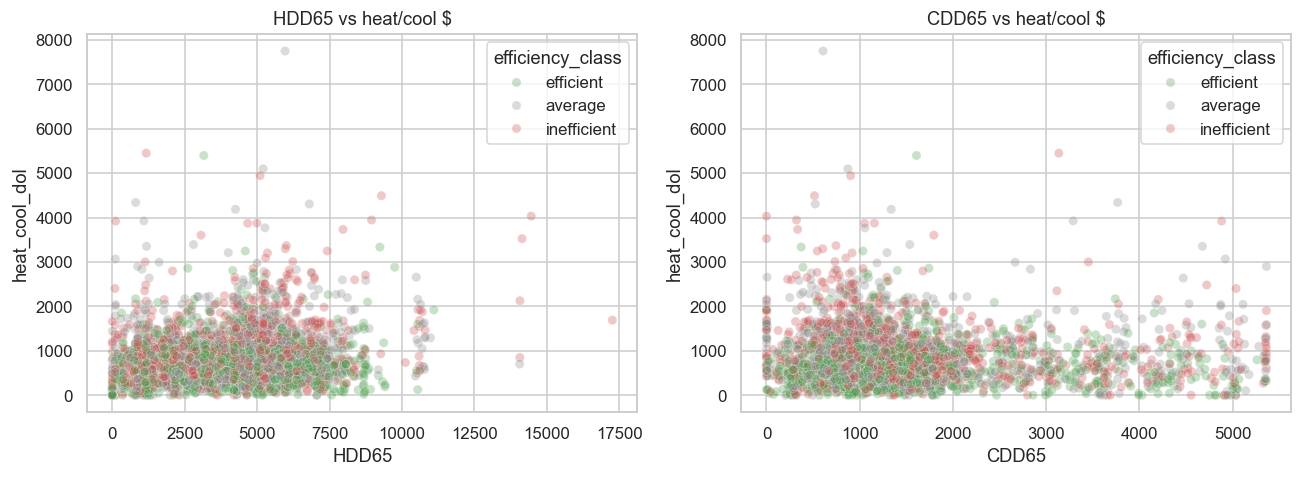

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.scatterplot(data=df.sample(min(3000, len(df)), random_state=0), x='HDD65', y='heat_cool_dol',
                hue='efficiency_class', alpha=0.3, ax=axes[0],
                palette={'efficient':'#4c9c4c', 'average':'#888', 'inefficient':'#cc4c4c'})
axes[0].set_title('HDD65 vs heat/cool $')
sns.scatterplot(data=df.sample(min(3000, len(df)), random_state=0), x='CDD65', y='heat_cool_dol',
                hue='efficiency_class', alpha=0.3, ax=axes[1],
                palette={'efficient':'#4c9c4c', 'average':'#888', 'inefficient':'#cc4c4c'})
axes[1].set_title('CDD65 vs heat/cool $')
plt.tight_layout()
plt.show()


## Summary of findings

- Weighted estimates differ meaningfully from unweighted (~5% on the mean), so we'll use `NWEIGHT` everywhere.
- Class balance is exactly equal within climate by construction — good for stratified splits.
- The strongest absolute correlates of `TOTALDOL` are size proxies; this is why classification uses `cost_per_sqft` rather than raw `TOTALDOL`.
- 'Inefficient' homes show a slightly larger share of spending in **water heating** and **other** (TVs, dryers, EVs, pools), and a slightly smaller share in heat/cool. Recommendation logic should not assume heat/cool dominates.
- Sentinel codes are concentrated in features that are categorically inapplicable (`STORIES` for apartments, `AGEDW` for homes without a dishwasher). Treating them as their own categorical level is more honest than dropping rows.

Next: `03_classification.ipynb` — multinomial logistic regression on `efficiency_class`.